# 1. Preparación del entorno

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import numpy as np
import os, shutil, math
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
RUTA_DATA = r'C:\Users\jacob\OneDrive - UFV\IA 2\Talleres\Taller 3 CNN\Data'
# Detectar clases desde las subcarpetas
clases = sorted([c for c in os.listdir(RUTA_DATA)
                 if os.path.isdir(os.path.join(RUTA_DATA, c))])

In [3]:
print(f"{'Clases':<12} {'Imágenes por clase':>10}")
conteos = {}
for clase in clases:
    n = len(os.listdir(os.path.join(RUTA_DATA, clase)))
    conteos[clase] = n

total = sum(conteos.values())
for clase, n in conteos.items():
    print(f"{clase:<12} {n:>10}   {n/total*100:>5.1f}%")

print(f"{'TOTAL':<12} {total:>10}")

#Miro el tamaño de una imagen de ejemplo para saber a qué tamaño redimensionar después
primera_clase = clases[0]
primer_archivo = os.listdir(os.path.join(RUTA_DATA, primera_clase))[0]
img_muestra = Image.open(os.path.join(RUTA_DATA, primera_clase, primer_archivo))
print(f"\nTamaño de imagen: {img_muestra.size}")

Clases       Imágenes por clase
Angry             10148    17.2%
Fear               9732    16.5%
Happy             18439    31.2%
Sad               12553    21.2%
Suprise            8227    13.9%
TOTAL             59099

Tamaño de imagen: (48, 48)


Muestro un ejemplo de 5 imagenes por clase 

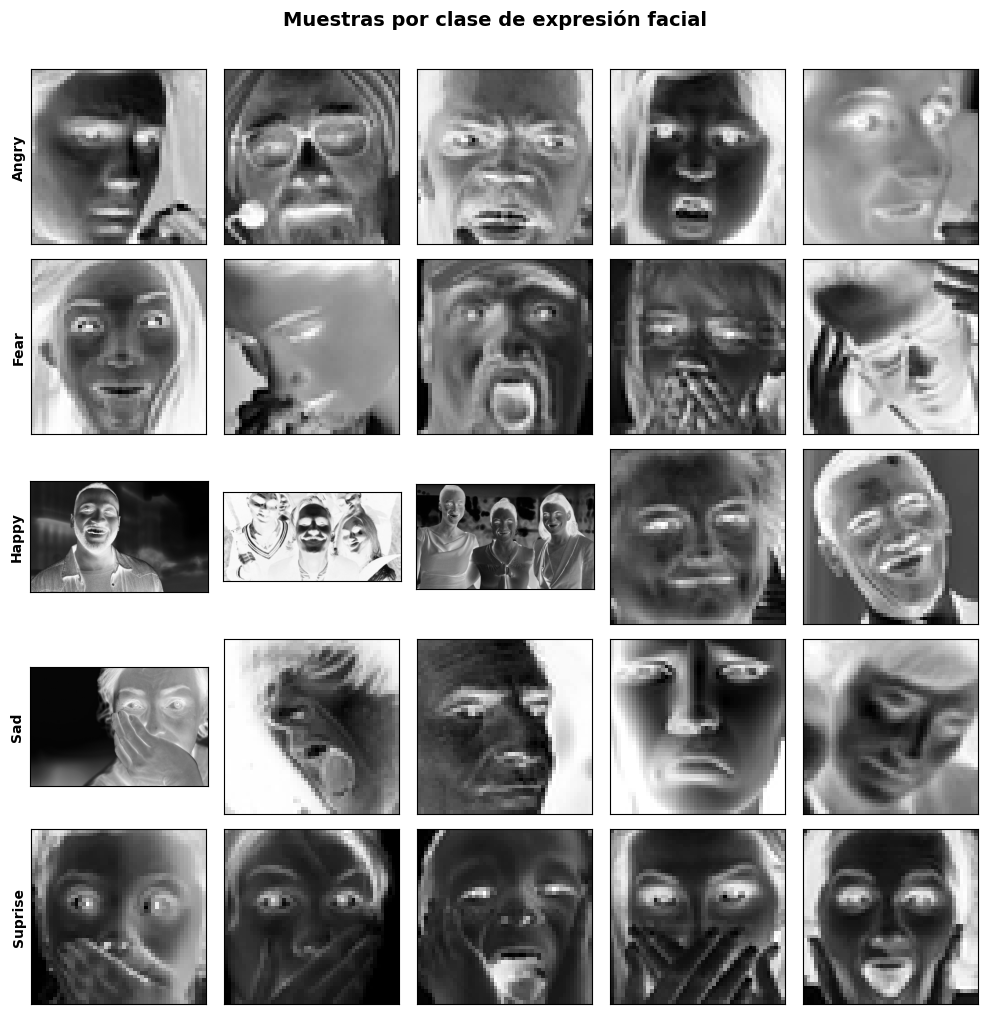

In [4]:
MUESTRAS_POR_CLASE = 5

fig, axes = plt.subplots(len(clases), MUESTRAS_POR_CLASE, figsize=(MUESTRAS_POR_CLASE * 2, len(clases) * 2))

for fila, clase in enumerate(clases):
    carpeta = os.path.join(RUTA_DATA, clase)
    archivos = os.listdir(carpeta)[:MUESTRAS_POR_CLASE]

    for col, archivo in enumerate(archivos):
        img = Image.open(os.path.join(carpeta, archivo)).convert('L')
        ax = axes[fila, col]
        ax.imshow(np.array(img), cmap=plt.cm.binary)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        if col == 0:
            ax.set_ylabel(clase, fontsize=10, fontweight='bold')

plt.suptitle('Muestras por clase de expresión facial', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Creo el Split de train, validacion y test en disco

In [5]:
# Proporciones 70 / 15 / 15
PROP_TRAIN = 0.70
PROP_VAL   = 0.15

RUTA_SPLIT = os.path.join(os.path.dirname(RUTA_DATA), 'Data_split')
RUTA_TRAIN = os.path.join(RUTA_SPLIT, 'train')
RUTA_VAL   = os.path.join(RUTA_SPLIT, 'val')
RUTA_TEST  = os.path.join(RUTA_SPLIT, 'test')

if os.path.exists(RUTA_SPLIT):
    print("⚠️  Data_split/ ya existe, no se repite la copia.")
else:
    np.random.seed(42)

    for clase in clases:
        archivos = np.array(os.listdir(os.path.join(RUTA_DATA, clase)))
        np.random.shuffle(archivos)

        n_total = len(archivos)
        n_train = int(n_total * PROP_TRAIN)
        n_val   = int(n_total * PROP_VAL)

        splits = {
            'train': archivos[:n_train],
            'val'  : archivos[n_train : n_train + n_val],
            'test' : archivos[n_train + n_val:]
        }

        for split_nombre, split_archivos in splits.items():
            destino = os.path.join(RUTA_SPLIT, split_nombre, clase)
            os.makedirs(destino, exist_ok=True)
            for archivo in split_archivos:
                shutil.copy(
                    os.path.join(RUTA_DATA, clase, archivo),
                    os.path.join(destino, archivo)
                )

    print("✅ Data_split/ creada")

# Verificar conteos
print(f"\n{'Clase':<12} {'Train':>7} {'Val':>7} {'Test':>7}")
print("-" * 35)
for clase in clases:
    n_tr = len(os.listdir(os.path.join(RUTA_TRAIN, clase)))
    n_va = len(os.listdir(os.path.join(RUTA_VAL,   clase)))
    n_te = len(os.listdir(os.path.join(RUTA_TEST,  clase)))
    print(f"{clase:<12} {n_tr:>7} {n_va:>7} {n_te:>7}")

⚠️  Data_split/ ya existe, no se repite la copia.

Clase          Train     Val    Test
-----------------------------------
Angry           7103    1522    1523
Fear            6812    1459    1461
Happy          12907    2765    2767
Sad             8787    1882    1884
Suprise         5758    1234    1235


Paso a hacer el procesamiento de los datos, basicamente prepararo las imágenes para que el modelo las pueda consumir durante el entrenamiento

In [6]:
TAMANO_IMG  = (48, 48)
TAMANO_LOTE = 32
NUM_CLASES  = len(clases)

# Generador TRAIN con augmentation y rescaling
generador_train = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 30,         
    width_shift_range  = 0.25,       
    height_shift_range = 0.25,       
    zoom_range         = [0.5, 1.5], 
    horizontal_flip    = True
)

# Generador VAL y TEST: en este caso solo normalización
generador_valtest = ImageDataGenerator(rescale=1./255)

Hemos usado ImageDataGenerator, que es una clase de Keras que hace dos cosas a la vez:
    - Normaliza las imágenes
    - Aplica transformaciones aleatorias
Los parámetros utilizados: 
    - rescale=1./255 : divide cada píxel por 255, después de esto quedan entre 0.0 y 1.0.
    - rotation_range=30 : rota cada imagen aleatoriamente entre -30° y +30°.
    - width_shift_range=0.25 : desplaza la imagen horizontalmente hasta un 25% del ancho.
    - height_shift_range=0.25 : igual pero vertical.
    - zoom_range=[0.5, 1.5] : aplica zoom aleatorio entre 50% (alejar) y 150% (acercar).
    - horizontal_flip=True : espeja la imagen horizontalmente de forma aleatoria, ya que una cara feliz espejada sigue siendo una cara feliz.

También tenemos el Generador de Validacion y test, pero a este solo le aplicamos normalización

Ahora pasamos a aplicar las transformaciones y normalización a TRAIN, TEST y VAL, como algún paramétro tenemos que destacar class_mode='categorical', este convierte las etiquetas a formato one-hot. Es decir, en lugar de decir clase 2, dice [0, 0, 1, 0, 0] y el shuffle=True, ya que mezcla las imágenes aleatoriamente en cada época para que el modelo no aprenda el orden

In [7]:
gen_train = generador_train.flow_from_directory(
    RUTA_TRAIN,
    target_size = TAMANO_IMG,
    color_mode  = 'grayscale',
    batch_size  = TAMANO_LOTE,
    class_mode  = 'categorical',
    shuffle     = True
)

gen_val = generador_valtest.flow_from_directory(
    RUTA_VAL,
    target_size = TAMANO_IMG,
    color_mode  = 'grayscale',
    batch_size  = TAMANO_LOTE,
    class_mode  = 'categorical',
    shuffle     = False
)

gen_test = generador_valtest.flow_from_directory(
    RUTA_TEST,
    target_size = TAMANO_IMG,
    color_mode  = 'grayscale',
    batch_size  = TAMANO_LOTE,
    class_mode  = 'categorical',
    shuffle     = False
)


Found 41367 images belonging to 5 classes.
Found 8862 images belonging to 5 classes.
Found 8870 images belonging to 5 classes.


Una vez transformadas la imagenes tenemos que asegurarnos de que la trandormación haya sido exitosa

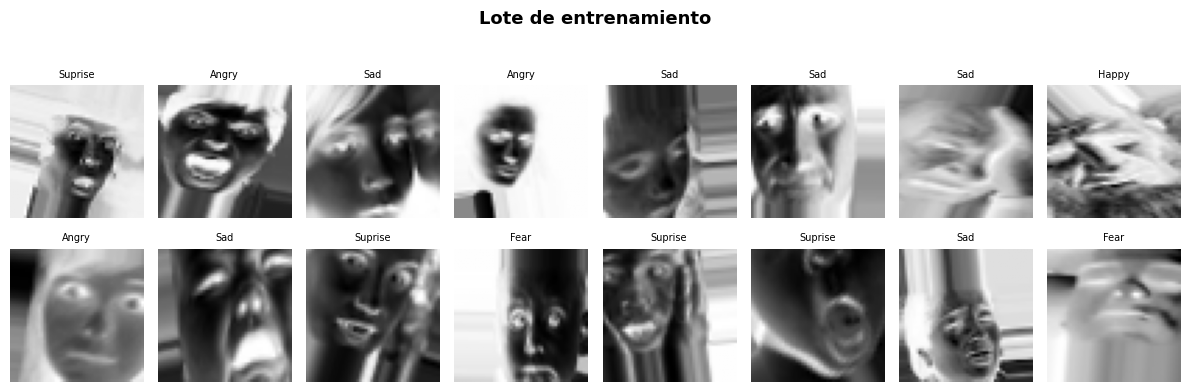

In [8]:
# primero pedimos un lote del generador de entrenamiento
X_batch, Y_batch = next(gen_train)

# obtengo el nombre de la clsae, por ejemplo -> 0: angry, 1: fear ...
idx_a_clase = {v: k for k, v in gen_train.class_indices.items()}

# representamos el lote para ver si las transformaciones se aplicaron
filas, columnas = 2, 8
fig, axes = plt.subplots(filas, columnas, figsize=(1.5 * columnas, 2 * filas))

for i in range(filas * columnas):
    ax = axes[i // columnas, i % columnas]
    ax.imshow(X_batch[i].reshape(TAMANO_IMG), cmap='gray_r')
    ax.set_title(idx_a_clase[np.argmax(Y_batch[i])], fontsize=7)
    ax.axis('off')

plt.suptitle('Lote de entrenamiento', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. Implementación


In [9]:
EPOCAS = 20


def entrenar_y_graficar(modelo, nombre_modelo):
    hist = modelo.fit(
        gen_train,
        epochs=EPOCAS,
        validation_data=gen_val,
        verbose=1
    )

    train_acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    epocas = list(range(1, len(val_acc) + 1))

    mejor_idx = int(np.argmax(val_acc))
    mejor_epoca = epocas[mejor_idx]
    mejor_val_acc = val_acc[mejor_idx]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='Train Loss', color='red', linewidth=2)
    plt.plot(hist.history['val_loss'], label='Val Loss', color='orange', linewidth=2, linestyle='--')
    plt.title(f'{nombre_modelo} - Loss')
    plt.xlabel('Época')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epocas, train_acc, label='Train Accuracy', color='green', linewidth=2)
    plt.plot(epocas, val_acc, label='Val Accuracy', color='blue', linewidth=2, linestyle='--')
    plt.scatter(mejor_epoca, mejor_val_acc, color='black', s=70, zorder=5, label=f'Mejor val_accuracy ({mejor_val_acc:.4f})')
    plt.annotate(
        f'epoca {mejor_epoca} | val_acc={mejor_val_acc:.4f}',
        (mejor_epoca, mejor_val_acc),
        textcoords='offset points',
        xytext=(12, 10),
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.8)
    )
    plt.title(f'{nombre_modelo} - Accuracy')
    plt.xlabel('Época')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'{nombre_modelo}')
    print(f'   mejor val_accuracy: {mejor_val_acc:.4f} ({mejor_val_acc*100:.2f}%) en la época {mejor_epoca}')

    return hist

Para poder encontrar el mejor modelo vamos a entrenar modelos con diferentes combinaciones de hiperparámetros, para eso vamos a definir un función que contrulle y compila un modelo según los hiperparámetros que se le pasan.

## Modelo 1

- capas ocultas -> 32, 64, 128, 256
- Dropout 0.5
- capas densas -> 100
- lr -> 0.001
- épocas -> 20
- kernel -> 5x5

c:\Users\jacob\OneDrive - UFV\IA 2\Talleres\Taller 3 CNN\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 159s 121ms/step - accuracy: 0.2974 - loss: 1.5824 - val_accuracy: 0.3021 - val_loss: 1.5580
Epoch 2/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 97s 75ms/step - accuracy: 0.3098 - loss: 1.5564 - val_accuracy: 0.2660 - val_loss: 1.5869
Epoch 3/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 92s 71ms/step - accuracy: 0.3131 - loss: 1.5499 - val_accuracy: 0.2405 - val_loss: 1.6237
Epoch 4/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 114s 88ms/step - accuracy: 0.3194 - loss: 1.5413 - val_accuracy: 0.3074 - val_loss: 1.7269
Epoch 5/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 110s 85ms/step - accuracy: 0.3243 - loss: 1.5344 - val_accuracy: 0.3292 - val_loss: 1.5640
Epoch 6/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 141s 84ms/step - accuracy: 0.3328 - loss: 1.5207 - val_accuracy: 0.3255 - val_loss: 1.5262
Epoch 7/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 114s 88ms/step - accuracy: 0.3396 - loss: 1.5082 - val_accuracy: 0.3413 - val_loss: 1.4820
Epoch 8/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 129s 100ms/step - accuracy: 

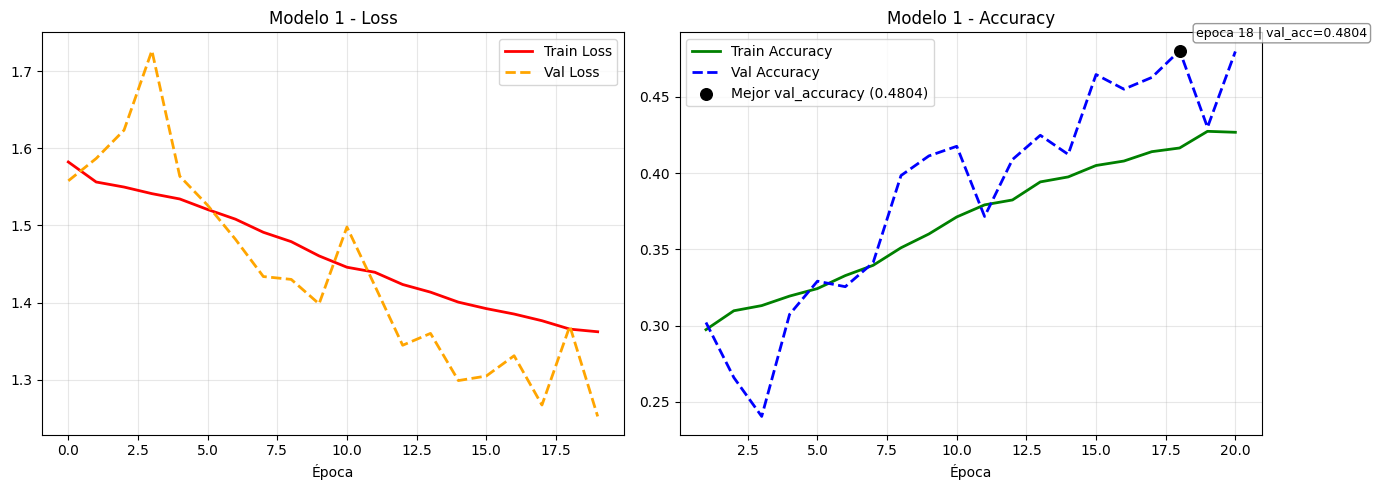

Modelo 1
   mejor val_accuracy: 0.4804 (48.04%) en la época 18


In [10]:
# Convolucion simple por bloque + downsampling con stride=2
def construir_modelo1():
    modelo = tf.keras.Sequential([

        tf.keras.layers.Conv2D(32, (3, 3), strides=2, activation='relu', padding='same', input_shape=(48, 48, 1)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(64, (3, 3), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(128, (3, 3), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(NUM_CLASES, activation='softmax')
    ])
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

modelo1 = construir_modelo1()
hist1 = entrenar_y_graficar(modelo1, 'Modelo 1')

## Modelo 2


- capas ocultas -> 32, 64, 128
- Dropout 0.5
- capas densas -> 128, 64
- lr -> 0.001
- épocas -> 20
- kernel -> 5x5

In [12]:
def construir_modelo2():
    modelo = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (5, 5), strides=2, activation='relu', padding='same', input_shape=(48, 48, 1)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(64, (5, 5), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(128, (5, 5), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Dropout(0.5),
        
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(NUM_CLASES, activation='softmax')
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

Entreno el modelo y muestro sus gráficas.

Epoch 1/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 110s 82ms/step - accuracy: 0.3064 - loss: 1.5633 - val_accuracy: 0.2117 - val_loss: 2.0294
Epoch 2/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 101s 78ms/step - accuracy: 0.3180 - loss: 1.5392 - val_accuracy: 0.3285 - val_loss: 1.5355
Epoch 3/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 106s 82ms/step - accuracy: 0.3275 - loss: 1.5317 - val_accuracy: 0.3492 - val_loss: 1.5080
Epoch 4/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 103s 80ms/step - accuracy: 0.3333 - loss: 1.5198 - val_accuracy: 0.3007 - val_loss: 1.5619
Epoch 5/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 104s 81ms/step - accuracy: 0.3503 - loss: 1.4963 - val_accuracy: 0.4085 - val_loss: 1.4065
Epoch 6/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 104s 81ms/step - accuracy: 0.3655 - loss: 1.4723 - val_accuracy: 0.4216 - val_loss: 1.3929
Epoch 7/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 105s 81ms/step - accuracy: 0.3836 - loss: 1.4436 - val_accuracy: 0.4369 - val_loss: 1.3426
Epoch 8/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 102s 79ms/step - accuracy: 

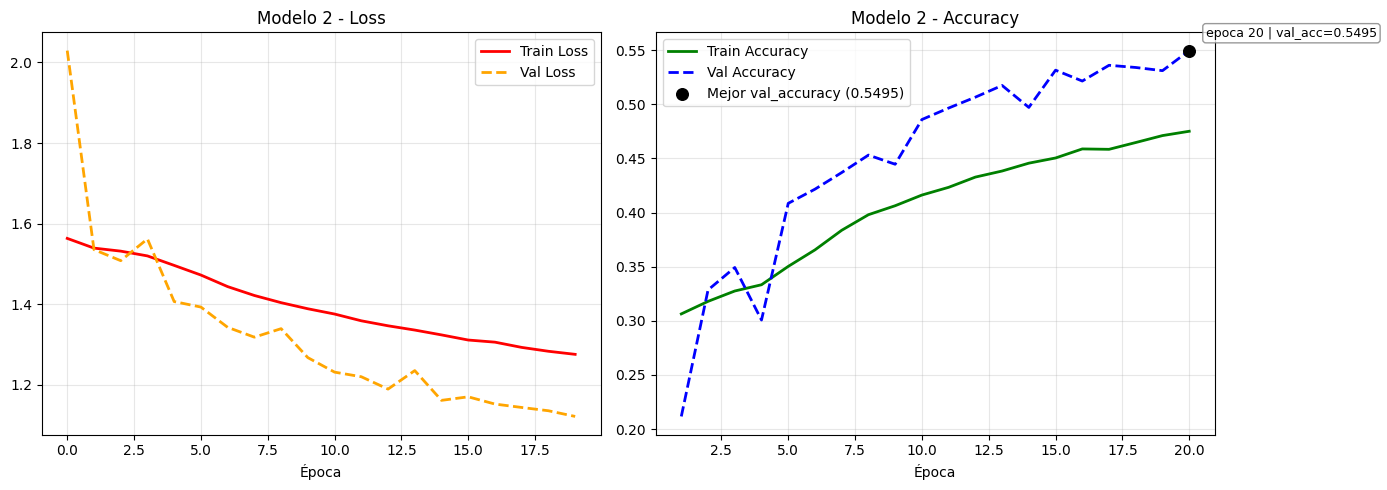

Modelo 2
   mejor val_accuracy: 0.5495 (54.95%) en la época 20


In [13]:
modelo2 = construir_modelo2()
hist2 = entrenar_y_graficar(modelo2, 'Modelo 2')

## Modelo 3

- capas ocultas -> 32, 64, 128
- Dropout 0.5
- capas densas -> 128
- lr -> 0.001
- épocas -> 20
- kernel -> 3x3

In [14]:
def construir_modelo3():
    modelo = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), strides=2, activation='relu', padding='same', input_shape=(48, 48, 1)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(64, (3, 3), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(128, (3, 3), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Dropout(0.5),
        
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(NUM_CLASES, activation='softmax')
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

Entreno el modelo y muestro sus gráficas.

Epoch 1/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 108s 82ms/step - accuracy: 0.3051 - loss: 1.5655 - val_accuracy: 0.3121 - val_loss: 1.5613
Epoch 2/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 100s 77ms/step - accuracy: 0.3142 - loss: 1.5441 - val_accuracy: 0.3171 - val_loss: 1.5371
Epoch 3/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 104s 81ms/step - accuracy: 0.3211 - loss: 1.5381 - val_accuracy: 0.3295 - val_loss: 1.5188
Epoch 4/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 127s 98ms/step - accuracy: 0.3292 - loss: 1.5290 - val_accuracy: 0.1737 - val_loss: 1.9355
Epoch 5/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 210s 163ms/step - accuracy: 0.3315 - loss: 1.5207 - val_accuracy: 0.3137 - val_loss: 1.5165
Epoch 6/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 164s 127ms/step - accuracy: 0.3416 - loss: 1.5059 - val_accuracy: 0.3691 - val_loss: 1.4654
Epoch 7/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 100s 77ms/step - accuracy: 0.3540 - loss: 1.4893 - val_accuracy: 0.3847 - val_loss: 1.4396
Epoch 8/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 193s 150ms/step - accurac

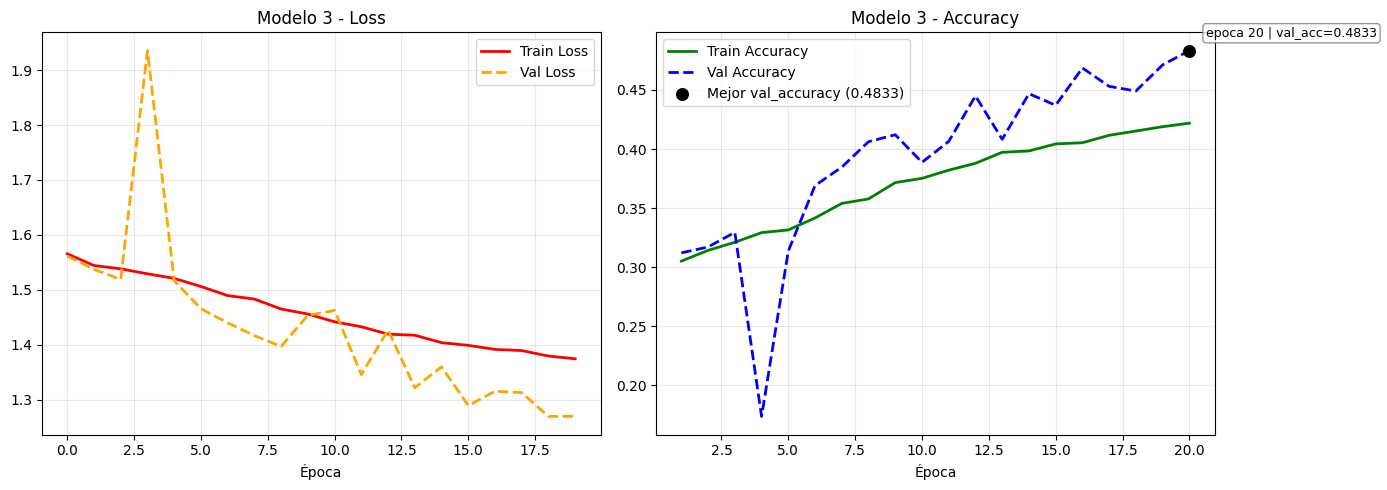

Modelo 3
   mejor val_accuracy: 0.4833 (48.33%) en la época 20


In [15]:
modelo3 = construir_modelo3()
hist3 = entrenar_y_graficar(modelo3, 'Modelo 3')

## Modelo 4

- capas ocultas -> 32, 64, 128, 256
- Dropout 0.5
- capas densas -> 128
- lr -> 0.001
- épocas -> 20
- kernel -> 3x3

In [16]:
def construir_modelo4():
    modelo = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), strides=2, activation='relu', padding='same', input_shape=(48, 48, 1)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(64, (3, 3), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(128, (3, 3), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(256, (3, 3), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(NUM_CLASES, activation='softmax')
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

Entreno el modelo y muestro sus gráficas.

In [ ]:
modelo4 = construir_modelo4()
hist4 = entrenar_y_graficar(modelo4, 'Modelo 4')

Epoch 1/20


## Modelo 5

- capas ocultas -> 32, 64, 128
- Dropout 0.5
- capas densas -> 128, 64
- lr -> 0.001
- épocas -> 20
- kernel -> 3x3

In [ ]:
def construir_modelo5():
    modelo = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), strides=2, activation='relu', padding='same', input_shape=(48, 48, 1)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(64, (3, 3), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(128, (3, 3), strides=2, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Dropout(0.5),
        
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(NUM_CLASES, activation='softmax')
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

Entreno el modelo y muestro sus gráficas.

Epoch 1/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 89s 68ms/step - accuracy: 0.3168 - loss: 1.5433 - val_accuracy: 0.3488 - val_loss: 1.5012
Epoch 2/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 88s 68ms/step - accuracy: 0.3386 - loss: 1.5139 - val_accuracy: 0.3790 - val_loss: 1.4485
Epoch 3/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 92s 71ms/step - accuracy: 0.3547 - loss: 1.4930 - val_accuracy: 0.4040 - val_loss: 1.4011
Epoch 4/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 106s 82ms/step - accuracy: 0.3644 - loss: 1.4763 - val_accuracy: 0.4268 - val_loss: 1.3723
Epoch 5/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 102s 79ms/step - accuracy: 0.3817 - loss: 1.4432 - val_accuracy: 0.4553 - val_loss: 1.2992
Epoch 6/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 91s 70ms/step - accuracy: 0.3951 - loss: 1.4157 - val_accuracy: 0.4718 - val_loss: 1.2565
Epoch 7/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 91s 70ms/step - accuracy: 0.4099 - loss: 1.3873 - val_accuracy: 0.4851 - val_loss: 1.2335
Epoch 8/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 92s 71ms/step - accuracy: 0.4216

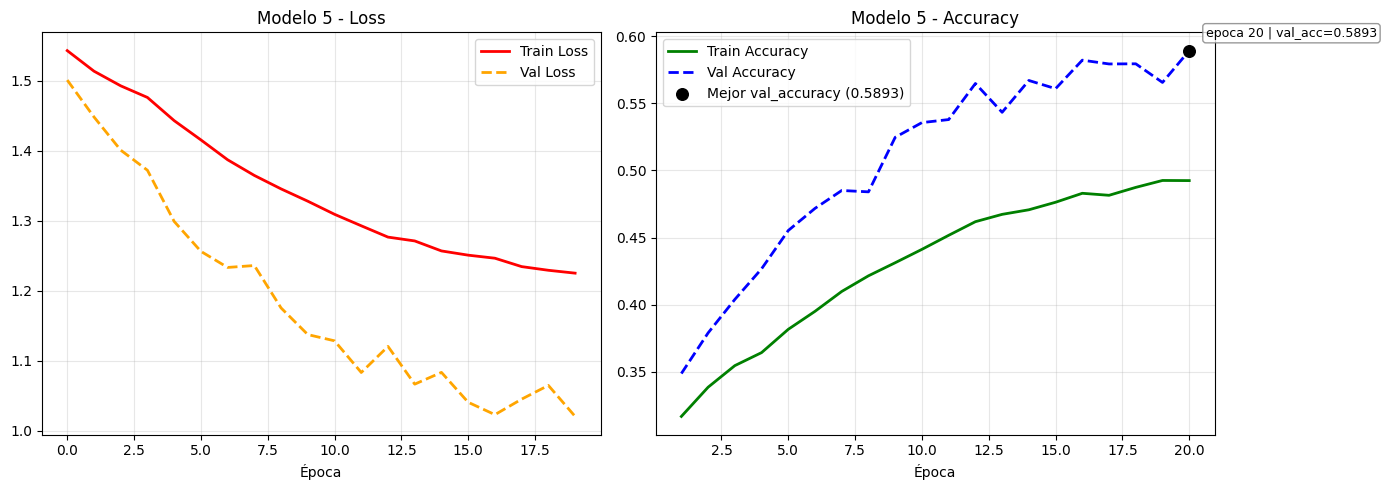

Modelo 5
   mejor val_accuracy: 0.5893 (58.93%) en la época 20


In [ ]:
modelo5 = construir_modelo5()
hist5 = entrenar_y_graficar(modelo5, 'Modelo 5')